# (Not) Optimising the algorithm

>**TL;DR** I tried a different factorisation but it, obviously in retrospect, was far worse than the chunking in the previous notebook. I'll leave this up though as the algorithm works and it runs on a 3*3 no problem. 

>For real speed improvements, use the JAX version in `dev container/src` This is 3 seconds per turn on a 4 * 4 grid (rather than 5 minutes per turn for the original numpy implementation).

Here was my thinking:

We don't care about the state of each chunk, we just care about how many of each chunk type we have.

For example, if chunk 0 is 'win in 2' and chunk 1 is 'win in 1', that's the same value as chunk 1 being 'win in 2' and chunk 0 being 'win in 1'.

We don't care about the count of empty or unwinnable chunks.

This means we need win_length counts for O and X. For example, on a 3-win board:

- 0 away (won count)
- 1 away (win / lose opportunity count)
- 2 away (advantage / disadvantage count)

As shown below, on a 4 * 4 grid with win length we get the following max available of each count:

Player O:
- 0 away: 4
- 1 away: 11
- 2 away: 14

Player X:
- 0 away: 4
- 1 away: 9
- 2 away: 13

> **NOTE:** This seemed good - (2 * win_length) count-factors on any board size and small number of count labels in each. What I failed to notice (until I came to build the A matrix) was that the counts would each need to depend on all cells, effectively encoding the chunk count for every possible game. You might think to put them in the world state, but then you just shift the problem into the B matrix as the transition would depend on every cell state.

In [1]:
import time
import numpy as np
import matplotlib.pyplot as plt
from pymdp.agent import Agent
from pymdp import utils
from copy import deepcopy

CELL_EMPTY = 0
CELL_O = 1
CELL_X = 2
cell_labels = ["Empty", "O", "X"]

def get_all_chunks(grid_size, win_length):
    """Get all possible winning chunks (lines) on the board."""
    chunks = []
    
    # Rows
    for row in range(grid_size):
        for col in range(grid_size - win_length + 1):
            chunks.append([(row, col + i) for i in range(win_length)])
    
    # Columns
    for col in range(grid_size):
        for row in range(grid_size - win_length + 1):
            chunks.append([(row + i, col) for i in range(win_length)])
    
    # Diagonals (top-left to bottom-right)
    for row in range(grid_size - win_length + 1):
        for col in range(grid_size - win_length + 1):
            chunks.append([(row + i, col + i) for i in range(win_length)])
    
    # Anti-diagonals (top-right to bottom-left)
    for row in range(grid_size - win_length + 1):
        for col in range(win_length - 1, grid_size):
            chunks.append([(row + i, col - i) for i in range(win_length)])
    
    return chunks

def classify_chunk(win_length, board, chunk):
    """Classify a chunk based on its current state."""
    cells = [board[r][c] for r, c in chunk]
    x_count = cells.count(CELL_X)
    o_count = cells.count(CELL_O)
    
    # Both players have marks - unwinnable
    if x_count > 0 and o_count > 0:
        return 'Unwinnable'
    
    # All empty
    if x_count == 0 and o_count == 0:
        return 'Empty'
    
    # X progress
    if x_count > 0:
        away = win_length - x_count
        return f'XIn{away}'

    
    # O progress
    if o_count > 0:
        away = win_length - o_count
        return f'OIn{away}'
        
def check_winner(board, chunks):
    """Check if there's a winner."""
    for chunk in chunks:
        cells = [board[r][c] for r, c in chunk]
        if all(c == CELL_X for c in cells):
            return CELL_X
        if all(c == CELL_O for c in cells):
            return CELL_O
    return None
    
def count_chunk_states(win_length, board, chunks):
    """Count chunks in each state."""
    counts = {}
    for chunk in chunks:
        state = classify_chunk(win_length, board, chunk)
        if state != 'Unwinnable' and state != 'Empty':  # Skip unwinnable and empty chunks
            counts[state] = counts.get(state, 0) + 1
    return counts

## Max Chunk Counts (Naive)

As shown above, we need to know the number of chunk_count states to create for each chunk size.

This only needs to be done once at initialisation and could be cached for future runs.

A naive algorithm searches all possible games and takes about 5 mins for a 4 * 4 grid.

In [2]:
def get_max_chunk_counts(grid_size, win_length, initial_player = CELL_O):
    
    # Initialize board and get all chunks
    chunks = get_all_chunks(grid_size, win_length)
    
    # Initialize max counts for all possible states
    max_counts = {'Empty': 0, 'Unwinnable': 0}
    for k in range(win_length + 1):
        max_counts[f'XIn{k}'] = 0
        max_counts[f'OIn{k}'] = 0
    
    # BFS to explore all legal game states
    from collections import deque
    
    initial_board = [['' for _ in range(grid_size)] for _ in range(grid_size)]
    queue = deque([(initial_board, initial_player)])  # (board, next_player)
    visited = set()
    
    def board_to_tuple(board):
        return tuple(tuple(row) for row in board)
    
    while queue:
        board, next_player = queue.popleft()
        board_key = board_to_tuple(board)
        
        if board_key in visited:
            continue
        visited.add(board_key)
        
        # Check if game is already over (shouldn't happen, but safety check)
        if check_winner(board, chunks):
            # Count terminal state
            current_counts = count_chunk_states(win_length, board, chunks)
            for state, count in current_counts.items():
                max_counts[state] = max(max_counts[state], count)
            continue
        
        # Count current state (non-terminal)
        current_counts = count_chunk_states(win_length, board, chunks)
        for state, count in current_counts.items():
            max_counts[state] = max(max_counts[state], count)
        
        # Try all possible next moves
        for row in range(grid_size):
            for col in range(grid_size):
                if board[row][col] == '':
                    # Make move
                    new_board = [row[:] for row in board]
                    new_board[row][col] = next_player
                    
                    # Check if this move ends the game
                    winner = check_winner(new_board, chunks)
                    
                    # If this creates a winner, add as terminal state
                    if winner:
                        # Count the winning state
                        new_board_key = board_to_tuple(new_board)
                        if new_board_key not in visited:
                            visited.add(new_board_key)
                            terminal_counts = count_chunk_states(win_length, new_board, chunks)
                            for state, count in terminal_counts.items():
                                max_counts[state] = max(max_counts[state], count)
                    else:
                        # Add to queue with opposite player for further exploration
                        next_turn = CELL_O if next_player == CELL_X else CELL_X
                        queue.append((new_board, next_turn))
    
    return max_counts

print("3x3 board, win_length=3:\n")

start = time.time()   
result = get_max_chunk_counts(3, 3)
elapsed = time.time() - start
for state, count in sorted(result.items()):
    if count > 0:
        print(f"  {state}: {count}")

print(f"\nElapsed time: {elapsed:.2f} seconds\n")

print("\n4x4 board, win_length=3:\n")

start = time.time()   
result = get_max_chunk_counts(4, 3)
elapsed = time.time() - start
for state, count in sorted(result.items()):
    if count > 0:
        print(f"  {state}: {count}")

print(f"\nElapsed time: {elapsed:.2f} seconds")

3x3 board, win_length=3:

  OIn0: 2
  OIn1: 3
  OIn2: 5
  XIn0: 1
  XIn1: 3
  XIn2: 4

Elapsed time: 0.08 seconds


4x4 board, win_length=3:

  OIn0: 4
  OIn1: 11
  OIn2: 14
  XIn0: 4
  XIn1: 9
  XIn2: 13

Elapsed time: 292.63 seconds


## Max Chunk Counts (with Symmetry)

If we take advantage of the rotational and reflective symmetry of the board, we can drastically reduce the search space.

In [3]:
def get_max_chunk_counts_fast(grid_size, win_length, initial_player = CELL_O):
    
    # Initialize board and get all chunks
    chunks = get_all_chunks(grid_size, win_length)
    
    # Initialize max counts for all possible states
    # Only track X and O progress states
    max_counts = {}
    for k in range(win_length):  # 0 to win_length-1 (not including win_length)
        max_counts[f'XIn{k}'] = 0
        max_counts[f'OIn{k}'] = 0
    
    # BFS to explore all legal game states
    from collections import deque
    
    initial_board = [[CELL_EMPTY for _ in range(grid_size)] for _ in range(grid_size)]
    queue = deque([(initial_board, initial_player)])  # (board, next_player)
    visited = set()
    
    def board_to_tuple(board):
        return tuple(tuple(row) for row in board)
    
    def rotate_90(board):
        """Rotate board 90 degrees clockwise."""
        n = len(board)
        return [[board[n-1-j][i] for j in range(n)] for i in range(n)]
    
    def flip_horizontal(board):
        """Flip board horizontally."""
        return [row[::-1] for row in board]
    
    def get_canonical_form(board):
        """Get the canonical (lexicographically smallest) form among all symmetries."""
        n = len(board)
        forms = []
        
        # Generate all 8 symmetries
        current = board
        for _ in range(4):  # 4 rotations
            forms.append(board_to_tuple(current))
            forms.append(board_to_tuple(flip_horizontal(current)))
            current = rotate_90(current)
        
        # Return the smallest one
        return min(forms)
    
    while queue:
        board, next_player = queue.popleft()
        board_key = get_canonical_form(board)
        
        if board_key in visited:
            continue
        visited.add(board_key)
        
        # Check if game is already over (shouldn't happen, but safety check)
        if check_winner(board, chunks):
            # Count terminal state
            current_counts = count_chunk_states(win_length, board, chunks)
            for state, count in current_counts.items():
                max_counts[state] = max(max_counts[state], count)
            continue
        
        # Count current state (non-terminal)
        current_counts = count_chunk_states(win_length, board, chunks)
        for state, count in current_counts.items():
            max_counts[state] = max(max_counts[state], count)
        
        # Try all possible next moves
        for row in range(grid_size):
            for col in range(grid_size):
                if board[row][col] == CELL_EMPTY:
                    # Make move
                    new_board = [row[:] for row in board]
                    new_board[row][col] = next_player
                    
                    # Check if this move ends the game
                    winner = check_winner(new_board, chunks)
                    
                    # If this creates a winner, add as terminal state
                    if winner:
                        # Count the winning state
                        new_board_key = get_canonical_form(new_board)
                        if new_board_key not in visited:
                            visited.add(new_board_key)
                            terminal_counts = count_chunk_states(win_length, new_board, chunks)
                            for state, count in terminal_counts.items():
                                max_counts[state] = max(max_counts[state], count)
                    else:
                        # Add to queue with opposite player for further exploration
                        next_turn = CELL_O if next_player == CELL_X else CELL_X
                        queue.append((new_board, next_turn))
    
    return max_counts

print("3x3 board, win_length=3:")

start = time.time()   
result = get_max_chunk_counts_fast(3, 3)
elapsed = time.time() - start
for state, count in sorted(result.items()):
    if count > 0:
        print(f"  {state}: {count}")

print(f"\nCompleted in {elapsed:.3f} seconds\n")

print("\n4x4 board, win_length=3:")

start = time.time()
result = get_max_chunk_counts_fast(4, 3)
elapsed = time.time() - start
for state, count in sorted(result.items()):
    if count > 0:
        print(f"  {state}: {count}")

print(f"\nCompleted in {elapsed:.3f} seconds\n")

3x3 board, win_length=3:
  OIn0: 2
  OIn1: 3
  OIn2: 5
  XIn0: 1
  XIn1: 3
  XIn2: 4

Completed in 0.025 seconds


4x4 board, win_length=3:
  OIn0: 4
  OIn1: 11
  OIn2: 14
  XIn0: 4
  XIn1: 9
  XIn2: 13

Completed in 55.819 seconds



## Chunk Counts for Board State

We also need to be able to calculate the chunk counts for a given board state.

This will be used when initialising the A matrix to assign chunk count observations to cell combinations.

Every chunk_count class (2 * win_length for the win and loss cases) will need to depend on all cells (whereas when we directly observed chunks they only depended on the win_length cells that they comprised of).

In [4]:
def get_chunk_counts(cells, grid_size, win_length):

    # Convert flat list to 2D board
    board = []
    for i in range(grid_size):
        row = cells[i * grid_size:(i + 1) * grid_size]
        board.append(row)
    
    # Get all chunks and count their states
    chunks = get_all_chunks(grid_size, win_length)
    
    # Initialize all possible states with 0
    # Only track X and O progress states (not empty, unwinnable, or win_length away)
    counts = {}
    for k in range(win_length):  # 0 to win_length-1 (not including win_length)
        counts[f'XIn{k}'] = 0
        counts[f'OIn{k}'] = 0
    
    # Count actual states
    for chunk in chunks:
        state = classify_chunk(win_length, board, chunk)
        if state in counts:  # Only count states we care about
            counts[state] += 1
    
    return counts

cells = [
    CELL_X, CELL_O, CELL_X,
    CELL_EMPTY, CELL_O,  CELL_O,
    CELL_X, CELL_O,  CELL_EMPTY
]

print("\n3 * 3 Board:")
for i in range(3):
    row = cells[i*3:(i+1)*3]
    print(' '.join(cell_labels[cell] if cell != CELL_EMPTY else '.' for cell in row))

counts = get_chunk_counts(cells, grid_size=3, win_length=3)
print("\nChunk counts:")
for state, count in sorted(counts.items()):
    print(f"  {state}: {count}")

cells = [
    CELL_X, CELL_O, CELL_X, CELL_EMPTY,
    CELL_EMPTY, CELL_O,  CELL_O, CELL_EMPTY,
    CELL_X, CELL_O,  CELL_EMPTY, CELL_EMPTY,
    CELL_EMPTY, CELL_EMPTY, CELL_EMPTY, CELL_EMPTY
]

print("\n4 * 4 Board:")
for i in range(4):
    row = cells[i*4:(i+1)*4]
    print(' '.join(cell_labels[cell] if cell != CELL_EMPTY else '.' for cell in row))

counts = get_chunk_counts(cells, grid_size=4, win_length=3)
print("\nChunk counts:")
for state, count in sorted(counts.items()):
    print(f"  {state}: {count}")


3 * 3 Board:
X O X
. O O
X O .

Chunk counts:
  OIn0: 1
  OIn1: 1
  OIn2: 0
  XIn0: 0
  XIn1: 1
  XIn2: 0

4 * 4 Board:
X O X .
. O O .
X O . .
. . . .

Chunk counts:
  OIn0: 1
  OIn1: 6
  OIn2: 4
  XIn0: 0
  XIn1: 1
  XIn2: 1


## Hidden States

The hidden states are as before, we are only modifying observations.

In [5]:
grid_size = 3
win_length = 3  # e.g. 3 for classic tic tac toe
n_cells = grid_size * grid_size

# Empty Count options (0 to n_cells inclusive,so 17 vals for 16 cells)
empty_count_states = list(range(0, n_cells + 1))

n_cell_states = 3 # "Empty", "O", "X"

PLAYER_O = 0
PLAYER_X = 1
n_turn_states = 2  # O's turn, X's turn

starting_mark = CELL_O
starting_player = PLAYER_O if starting_mark == CELL_O else PLAYER_X

ACTION_STAY = 0
ACTION_MARK = 1
n_empty_count_states = len(empty_count_states)

n_states = [n_cell_states] * n_cells + [n_turn_states] + [n_empty_count_states]

print(f"Number of states\n{n_cell_states} cell states * {n_cells} cells, 2 turn states, {n_empty_count_states} empty states:\n{n_states}")

Number of states
3 cell states * 9 cells, 2 turn states, 10 empty states:
[3, 3, 3, 3, 3, 3, 3, 3, 3, 2, 10]


## A Matrix: Observation -> State

The observation / state mapping (A) will have the chunk observations removed and the chunk_count observations added.

In [6]:
chunk_counts = dict(
    sorted({
        state: count + 1  # +1 for None state
        for state, count in get_max_chunk_counts_fast(grid_size, win_length, starting_mark).items()
    }.items())
)
chunk_counts

{'OIn0': 3, 'OIn1': 4, 'OIn2': 6, 'XIn0': 2, 'XIn1': 4, 'XIn2': 5}

We need to add + 1 to the max count to handle the 'none' case.

In [7]:
n_chunks = win_length * 2 # Win in 0 -> win_length-1, Lose in 0 -> win_length-1

chunk_obs_labels = dict(
    (state, [
        f'{state}_{i}'
        for i in range(chunk_counts[state])
    ])
    for state in chunk_counts.keys()
)

chunk_obs = chunk_counts.values()
cell_obs = [ 3 for _ in range(n_cells) ]
n_obs = [ *cell_obs, 2, len(empty_count_states), *chunk_obs ]

print(f"Chunk labels: {chunk_obs_labels}")
print(f"Number of Chunks: {n_chunks}")
print(f"Observation Dimensionalities: {n_obs}")

Chunk labels: {'OIn0': ['OIn0_0', 'OIn0_1', 'OIn0_2'], 'OIn1': ['OIn1_0', 'OIn1_1', 'OIn1_2', 'OIn1_3'], 'OIn2': ['OIn2_0', 'OIn2_1', 'OIn2_2', 'OIn2_3', 'OIn2_4', 'OIn2_5'], 'XIn0': ['XIn0_0', 'XIn0_1'], 'XIn1': ['XIn1_0', 'XIn1_1', 'XIn1_2', 'XIn1_3'], 'XIn2': ['XIn2_0', 'XIn2_1', 'XIn2_2', 'XIn2_3', 'XIn2_4']}
Number of Chunks: 6
Observation Dimensionalities: [3, 3, 3, 3, 3, 3, 3, 3, 3, 2, 10, 3, 4, 6, 2, 4, 5]


### Where it goes wrong...

The chunk counts have to depend on all cells. This is where the A matrix blows up and can't be used for more than 3 * 3.

Before we were

n_chunks * (2 * win_length+2) * cell_states^win_length

so for 4 * 4, win length 3

24 chunks * 8 chunk cases * 3^3 = **5184**

Now we are

chunk_count_cases * cell_states^cell_count

so again for 4 * 4, win length 3

(5 + 12 + 15 + 5 + 10 + 14) * 3^16 = **2,625,849,981**

Anyway, the move to chunk counts worked on a 3 * 3....

In [8]:
turn_idx = n_cells
empty_count_idx = n_cells + 1
chunk_start_idx = n_cells + 2

A_factor_list = [
    *[[i] for i in range(n_cells)],
    [turn_idx],
    [empty_count_idx],
    *([i for i in range(n_cells)] for _ in chunk_counts.items())
]

print(f"A dependencies: {A_factor_list}")

A dependencies: [[0], [1], [2], [3], [4], [5], [6], [7], [8], [9], [10], [0, 1, 2, 3, 4, 5, 6, 7, 8], [0, 1, 2, 3, 4, 5, 6, 7, 8], [0, 1, 2, 3, 4, 5, 6, 7, 8], [0, 1, 2, 3, 4, 5, 6, 7, 8], [0, 1, 2, 3, 4, 5, 6, 7, 8], [0, 1, 2, 3, 4, 5, 6, 7, 8]]


In [9]:
A = utils.obj_array(len(n_obs))
for i in range(len(n_obs)):
    A[i] = np.zeros((n_obs[i],) + tuple([n_states[j] for j in A_factor_list[i]]))

# For each modality, its observation count followed by the counts of every hidden state it depends on.
for i in range(len(n_obs)):
    print(f"A[{i}] shape: {A[i].shape}")

A[0] shape: (3, 3)
A[1] shape: (3, 3)
A[2] shape: (3, 3)
A[3] shape: (3, 3)
A[4] shape: (3, 3)
A[5] shape: (3, 3)
A[6] shape: (3, 3)
A[7] shape: (3, 3)
A[8] shape: (3, 3)
A[9] shape: (2, 2)
A[10] shape: (10, 10)
A[11] shape: (3, 3, 3, 3, 3, 3, 3, 3, 3, 3)
A[12] shape: (4, 3, 3, 3, 3, 3, 3, 3, 3, 3)
A[13] shape: (6, 3, 3, 3, 3, 3, 3, 3, 3, 3)
A[14] shape: (2, 3, 3, 3, 3, 3, 3, 3, 3, 3)
A[15] shape: (4, 3, 3, 3, 3, 3, 3, 3, 3, 3)
A[16] shape: (5, 3, 3, 3, 3, 3, 3, 3, 3, 3)


In [10]:
def is_valid_board(board, grid_size, win_length):
    """
    Check if a tic-tac-toe board represents a valid game state.
    
    Args:
        board: Flat list of cells (0=empty, 1=player O, 2=player X)
        grid_size: Size of the square grid
        win_length: Number of consecutive marks needed to win
    
    Returns:
        bool: True if valid game state, False otherwise
    """
    # Count moves
    count_o = board.count(1)
    count_x = board.count(2)
    
    # Rule 1: O goes first, so count_o == count_x or count_o == count_x + 1
    if count_o not in [count_x, count_x + 1]:
        return False
    
    # Get all winning lines for each player
    o_lines = get_winning_lines(board, grid_size, win_length, 1)
    x_lines = get_winning_lines(board, grid_size, win_length, 2)
    
    # Rule 2: Both players can't win
    if o_lines and x_lines:
        return False
    
    # Rule 3: Multiple winning lines must share a common cell
    if o_lines and not lines_share_position(o_lines):
        return False
    if x_lines and not lines_share_position(x_lines):
        return False
    
    # Rule 4: If O won, game should have ended (count_o == count_x)
    if o_lines and count_o != count_x:
        return False
    
    # Rule 5: If X won, game should have ended (count_o == count_x + 1)
    if x_lines and count_o != count_x:
        return False
    
    return True


def get_winning_lines(board, grid_size, win_length, player):
    """Get all winning lines for a player as sets of cell positions."""
    winning_lines = []
    
    # Check rows
    for row in range(grid_size):
        for col in range(grid_size - win_length + 1):
            positions = [row * grid_size + col + i for i in range(win_length)]
            if all(board[pos] == player for pos in positions):
                winning_lines.append(set(positions))
    
    # Check columns
    for col in range(grid_size):
        for row in range(grid_size - win_length + 1):
            positions = [(row + i) * grid_size + col for i in range(win_length)]
            if all(board[pos] == player for pos in positions):
                winning_lines.append(set(positions))
    
    # Check diagonals (top-left to bottom-right)
    for row in range(grid_size - win_length + 1):
        for col in range(grid_size - win_length + 1):
            positions = [(row + i) * grid_size + col + i for i in range(win_length)]
            if all(board[pos] == player for pos in positions):
                winning_lines.append(set(positions))
    
    # Check anti-diagonals (top-right to bottom-left)
    for row in range(grid_size - win_length + 1):
        for col in range(win_length - 1, grid_size):
            positions = [(row + i) * grid_size + col - i for i in range(win_length)]
            if all(board[pos] == player for pos in positions):
                winning_lines.append(set(positions))
    
    return winning_lines


def lines_share_position(winning_lines):
    """Check if all winning lines share at least one common position."""
    if len(winning_lines) <= 1:
        return True
    
    # Find intersection of all winning lines
    common = winning_lines[0]
    for line in winning_lines[1:]:
        common = common & line
        if not common:
            return False
    
    return True

In [11]:
# Cell observations - identity
for i in range(n_cells):
    for state in range(3):
        A[i][state, state] = 1.

# Turn observation - identity
for state in range(2):
    A[turn_idx][state, state] = 1.0

# Empty count observation - identity
for state in range(n_empty_count_states):
    A[empty_count_idx][state, state] = 1.0

# Chunk observations.
for i, state in enumerate(sorted(chunk_counts.keys())):
    for cell_states in np.ndindex((3,) * n_cells):
        if not is_valid_board(cell_states, grid_size=grid_size, win_length=win_length):
            # print(f"Invalid board state {cell_states}, setting A[{chunk_start_idx + i}][{chunk_obs_labels[state][0]}, *cell_states] = 1.0")
            A[chunk_start_idx + i][0, *cell_states] = 1.0 # Shouldn't be possible to observe an invalid board state so set zero count
        else:
            counts = get_chunk_counts(cell_states, grid_size=grid_size, win_length=win_length)
            for count_state, count in sorted(counts.items()):
                if count_state == state:
                    # print(f"Setting A[{chunk_start_idx + i}][{chunk_obs_labels[state][count]}, {', '.join(cell_labels[s] for s in cell_states)}] = 1.0")
                    # print(f"Setting A[{chunk_start_idx + i}][{chunk_obs_labels[state][count]}, {', '.join(str(s) for s in cell_states)}] = 1.0")
                    try:
                        A[chunk_start_idx + i][count, *cell_states] = 1.0
                    except IndexError as e:
                        print(f"IndexError for A[{chunk_start_idx + i}][{state}:{count}, {', '.join(str(s) for s in cell_states)}]: {e}")


In [12]:
all_normalized = True
for m in range(len(A)):
    # Sum over observation dimension (axis 0) should be 1 for all state configs
    sum_over_obs = A[m].sum(axis=0)
    is_norm_m = np.allclose(sum_over_obs, 1.0)
    if not is_norm_m:
        print(f"Warning: A[{m}] is NOT normalized!")
        all_normalized = False

print(f"All A sub-arrays are normalized: {all_normalized}")

All A sub-arrays are normalized: True


## B Matrix: State -> Action -> State

B is the same as the last implementation, we are only changing observations, not state or transition dynamics.

In [13]:
n_controls = [2] * n_cells + [1, 1] # 2 actions for each cell: Stay or Mark. Null action for turn and empty count.
control_fac_idx = list(range(n_cells))  # only cell states are controllable

B_factor_list = []
for i in range(n_cells):
    B_factor_list.append([turn_idx, empty_count_idx, i])  # cell transitions depend on cell state, turn, empty count
B_factor_list.append([turn_idx])  # turn transition depends on turn state
B_factor_list.append([empty_count_idx])  # empty count transition depends on empty count state

print(f"Actions: {n_controls}")
print(f"Controllable items: {control_fac_idx}")
print(f"B dependencies: {B_factor_list}")

Actions: [2, 2, 2, 2, 2, 2, 2, 2, 2, 1, 1]
Controllable items: [0, 1, 2, 3, 4, 5, 6, 7, 8]
B dependencies: [[9, 10, 0], [9, 10, 1], [9, 10, 2], [9, 10, 3], [9, 10, 4], [9, 10, 5], [9, 10, 6], [9, 10, 7], [9, 10, 8], [9], [10]]


In [14]:
BO = utils.obj_array(len(n_states))
BX = utils.obj_array(len(n_states))
for i in range(n_cells):
    BO[i] = np.zeros((n_cell_states, n_turn_states, n_empty_count_states, n_cell_states, 2))
    BX[i] = np.zeros((n_cell_states, n_turn_states, n_empty_count_states, n_cell_states, 2))
    for prev in range(n_cell_states):
        for turn in range(n_turn_states):
            for emptyCount in range(n_empty_count_states):
                for act in range(2):  # Stay, Mark
                    if turn == PLAYER_O:

                        # Update O on O's turn
                        if act == ACTION_MARK and prev == CELL_EMPTY:
                            BO[i][CELL_O, turn, emptyCount, prev, act] = 1.0 # If marking an empty cell, it becomes O
                        else:
                            BO[i][prev, turn, emptyCount, prev,  act] = 1.0 # Otherwise unchanged
                        
                        # Update X on O's turn
                        if prev == CELL_EMPTY:
                            if emptyCount > 1: # If you are empty and not the only one you have a chance of being taken by O or remaining empty
                                BX[i][CELL_O, turn, emptyCount, prev, act] = 1.0 / emptyCount
                                BX[i][CELL_EMPTY, turn, emptyCount, prev, act] = (emptyCount - 1) / emptyCount
                            else: # You must be the only empty cell so will be taken by O
                                BX[i][CELL_O, turn, emptyCount, prev, act] = 1.0
                        else:
                            BX[i][prev, turn, emptyCount, prev, act] = 1.0 # If not empty, unchanged
                    else:

                        # Update X on X's turn
                        if act == ACTION_MARK and prev == CELL_EMPTY:
                            BX[i][CELL_X, turn, emptyCount, prev, act] = 1.0 # If marking an empty cell, it becomes X
                        else:
                            BX[i][prev, turn, emptyCount, prev,  act] = 1.0 # Otherwise unchanged
                        
                        # Update O on X's turn
                        if prev == CELL_EMPTY:
                            if emptyCount > 1: # If you are empty and not the only one you have a chance of being taken by X or remaining empty
                                BO[i][CELL_X, turn, emptyCount, prev, act] = 1.0 / emptyCount
                                BO[i][CELL_EMPTY, turn, emptyCount, prev, act] = (emptyCount - 1) / emptyCount
                            else: # You must be the only empty cell so will be taken by X
                                BO[i][CELL_X, turn, emptyCount, prev, act] = 1.0
                        else:
                            BO[i][prev, turn, emptyCount, prev, act] = 1.0 # If not empty, unchanged


# Turn transitions
BO[turn_idx] = np.zeros((n_turn_states, n_turn_states, 1))
BX[turn_idx] = np.zeros((n_turn_states, n_turn_states, 1))
for s in range(n_turn_states):
    for prev in range(n_turn_states):
        BO[turn_idx][s, prev, 0] = 1.0 if s == 1-prev else 0.0
        BX[turn_idx][s, prev, 0] = 1.0 if s == 1-prev else 0.0

# Empty count transitions
BO[empty_count_idx] = np.zeros((n_empty_count_states,  n_empty_count_states, 1))
BX[empty_count_idx] = np.zeros((n_empty_count_states,  n_empty_count_states, 1))
for s in range(n_empty_count_states):
    for prev in range(n_empty_count_states):
        BO[empty_count_idx][max(0, s-1), s, 0] = 1.0
        BX[empty_count_idx][max(0, s-1), s, 0] = 1.0

for i in range(len(BO)):
    print(f"BO[{i}] shape: {BO[i].shape}")

BO[0] shape: (3, 2, 10, 3, 2)
BO[1] shape: (3, 2, 10, 3, 2)
BO[2] shape: (3, 2, 10, 3, 2)
BO[3] shape: (3, 2, 10, 3, 2)
BO[4] shape: (3, 2, 10, 3, 2)
BO[5] shape: (3, 2, 10, 3, 2)
BO[6] shape: (3, 2, 10, 3, 2)
BO[7] shape: (3, 2, 10, 3, 2)
BO[8] shape: (3, 2, 10, 3, 2)
BO[9] shape: (2, 2, 1)
BO[10] shape: (10, 10, 1)


In [15]:
for f in range(len(BO)):
    B_f = BO[f]
    # Sum over first axis (next state)
    total_axes = tuple(range(1, len(B_f.shape)))
    for idx in np.ndindex(B_f.shape[1:]):
        col_sum = B_f[(slice(None),) + idx].sum()
        if not np.isclose(col_sum, 1.0):
            print(f"Warning: BO[{f}] column at {idx} sums to {col_sum:.3f}") 

In [16]:
for f in range(len(BX)):
    B_f = BX[f]
    # Sum over first axis (next state)
    total_axes = tuple(range(1, len(B_f.shape)))
    for idx in np.ndindex(B_f.shape[1:]):
        col_sum = B_f[(slice(None),) + idx].sum()
        if not np.isclose(col_sum, 1.0):
            print(f"Warning: BX[{f}] column at {idx} sums to {col_sum:.3f}")    

In [17]:
from pymdp.control import construct_policies  
import numpy as np  
  
policy_len = 1
all_policies = construct_policies(n_states, n_controls, policy_len=policy_len)  
  
# Keep policies where exactly one controllable factor changes per timestep  
policies = [  
    p for p in all_policies
    if all(np.count_nonzero(p[t, control_fac_idx]) == 1 for t in range(policy_len))  
]

print(f"Generated {len(policies)} policies:")
for i, pol in enumerate(policies):
    print(f"Policy {i}: {pol}")

Generated 9 policies:
Policy 0: [[0 0 0 0 0 0 0 0 1 0 0]]
Policy 1: [[0 0 0 0 0 0 0 1 0 0 0]]
Policy 2: [[0 0 0 0 0 0 1 0 0 0 0]]
Policy 3: [[0 0 0 0 0 1 0 0 0 0 0]]
Policy 4: [[0 0 0 0 1 0 0 0 0 0 0]]
Policy 5: [[0 0 0 1 0 0 0 0 0 0 0]]
Policy 6: [[0 0 1 0 0 0 0 0 0 0 0]]
Policy 7: [[0 1 0 0 0 0 0 0 0 0 0]]
Policy 8: [[1 0 0 0 0 0 0 0 0 0 0]]


## C Matrix: Preferred State

C is now defined in terms of preferred chunk counts rather than specific chunk states

In [18]:
CO = utils.obj_array_zeros(n_obs)
CX = utils.obj_array_zeros(n_obs)

# Cell obs: neutral
for i in range(n_cells):
    CO[i] = np.zeros(n_cell_states)
    CX[i] = np.zeros(n_cell_states)

# Turn obs: neutral
CO[turn_idx] = np.zeros(n_turn_states)
CX[turn_idx] = np.zeros(n_turn_states)

# Empty count obs: neutral
CO[empty_count_idx] = np.zeros(n_empty_count_states)
CX[empty_count_idx] = np.zeros(n_empty_count_states)

# Chunk obs: increasingly positive for stronger advantage counts, increasingly negative for stronger disadvantage counts.
# Advantage beats disadvantage at each level, and higher levels beat lower levels.
for i, (state, count) in enumerate(sorted(chunk_counts.items())):
    chunk_len = int(state[3:])
    chunk_len_score = (win_length - chunk_len)**5  # Square to make higher levels more valuable
    for c in range(count):
        if c == 0:
            CO[chunk_start_idx + i][c] = 0
            CX[chunk_start_idx + i][c] = 0
        elif state.startswith('OIn'):
            CO[chunk_start_idx + i][c] = chunk_len_score + c**2 + 1
            CX[chunk_start_idx + i][c] = - (chunk_len_score + c**2)
        elif state.startswith('XIn'):
            CX[chunk_start_idx + i][c] = chunk_len_score + c**2 + 1
            CO[chunk_start_idx + i][c] = - (chunk_len_score + c**2)

for i in range(len(CO)):
    print(f"CO[{i}] shape: {CO[i].shape}")

for i in range (len(chunk_counts)):
    print(f"Chunk obs CO[{chunk_start_idx + i}] values: {CO[chunk_start_idx + i]}")
    print(f"Chunk obs CX[{chunk_start_idx + i}] values: {CX[chunk_start_idx + i]}")

CO[0] shape: (3,)
CO[1] shape: (3,)
CO[2] shape: (3,)
CO[3] shape: (3,)
CO[4] shape: (3,)
CO[5] shape: (3,)
CO[6] shape: (3,)
CO[7] shape: (3,)
CO[8] shape: (3,)
CO[9] shape: (2,)
CO[10] shape: (10,)
CO[11] shape: (3,)
CO[12] shape: (4,)
CO[13] shape: (6,)
CO[14] shape: (2,)
CO[15] shape: (4,)
CO[16] shape: (5,)
Chunk obs CO[11] values: [  0. 245. 248.]
Chunk obs CX[11] values: [   0. -244. -247.]
Chunk obs CO[12] values: [ 0. 34. 37. 42.]
Chunk obs CX[12] values: [  0. -33. -36. -41.]
Chunk obs CO[13] values: [ 0.  3.  6. 11. 18. 27.]
Chunk obs CX[13] values: [  0.  -2.  -5. -10. -17. -26.]
Chunk obs CO[14] values: [   0. -244.]
Chunk obs CX[14] values: [  0. 245.]
Chunk obs CO[15] values: [  0. -33. -36. -41.]
Chunk obs CX[15] values: [ 0. 34. 37. 42.]
Chunk obs CO[16] values: [  0.  -2.  -5. -10. -17.]
Chunk obs CX[16] values: [ 0.  3.  6. 11. 18.]


## D Matrix : Starting State Belief

D is as before since the starting states haven't changed.

In [19]:
def getDForPlayer(starting_player, player):
    D = utils.obj_array(len(n_states))
    # Cell states
    for i in range(n_cells):
        d = np.zeros(n_cell_states)
        if starting_player == player:
            d[CELL_EMPTY] = 1.0 # All empty
        else:            
            d[CELL_EMPTY] = (n_cells - 1) / n_cells  # Most empty
            if player == PLAYER_O:
                d[CELL_X] = 1.0 / n_cells  # One will be marked by opponent
            else: 
                d[CELL_O] = 1.0 / n_cells
        D[i] = d

    # Turn state
    turn_d = np.zeros(n_turn_states)
    turn_d[starting_player] = 1.0
    D[n_cells] = turn_d

    # Empty count state
    empty_d = np.zeros(n_empty_count_states)
    empty_d[-1] = 1.0  # start with all cells empty (index n_cells - 1)
    D[n_cells+1] = empty_d
    return D


DO = getDForPlayer(starting_player=starting_player, player=PLAYER_O)
DX = getDForPlayer(starting_player=starting_player, player=PLAYER_X)

print("D matrices initialized for factorized state space:")
for i in range(len(DO)):
    print(f"DO[{i}] shape: {DO[i].shape}")
    print(f"State prior {i}: {DO[i]}")
for i in range(len(DX)):
    print(f"DX[{i}] shape: {DX[i].shape}")
    print(f"State prior {i}: {DX[i]}")

D matrices initialized for factorized state space:
DO[0] shape: (3,)
State prior 0: [1. 0. 0.]
DO[1] shape: (3,)
State prior 1: [1. 0. 0.]
DO[2] shape: (3,)
State prior 2: [1. 0. 0.]
DO[3] shape: (3,)
State prior 3: [1. 0. 0.]
DO[4] shape: (3,)
State prior 4: [1. 0. 0.]
DO[5] shape: (3,)
State prior 5: [1. 0. 0.]
DO[6] shape: (3,)
State prior 6: [1. 0. 0.]
DO[7] shape: (3,)
State prior 7: [1. 0. 0.]
DO[8] shape: (3,)
State prior 8: [1. 0. 0.]
DO[9] shape: (2,)
State prior 9: [1. 0.]
DO[10] shape: (10,)
State prior 10: [0. 0. 0. 0. 0. 0. 0. 0. 0. 1.]
DX[0] shape: (3,)
State prior 0: [0.88888889 0.11111111 0.        ]
DX[1] shape: (3,)
State prior 1: [0.88888889 0.11111111 0.        ]
DX[2] shape: (3,)
State prior 2: [0.88888889 0.11111111 0.        ]
DX[3] shape: (3,)
State prior 3: [0.88888889 0.11111111 0.        ]
DX[4] shape: (3,)
State prior 4: [0.88888889 0.11111111 0.        ]
DX[5] shape: (3,)
State prior 5: [0.88888889 0.11111111 0.        ]
DX[6] shape: (3,)
State prior 6: [0.

In [20]:
for f in range(len(DX)):
    D_f = DX[f]
    total = D_f.sum()
    if not np.isclose(total, 1.0):
        print(f"Warning: D[{f}] sums to {total:.3f}")

## Generative Process: The Environment

The environment now needs to return the chunk counts in its observation.

In [21]:
def get_chunks_as_indices(grid_size, win_length):
    """Return a list of lists, each sublist is indices of a winning line."""
    chunks = []
    # Rows
    for r in range(grid_size):
        for c in range(grid_size - win_length + 1):
            chunks.append([r * grid_size + c + i for i in range(win_length)])
    # Columns
    for c in range(grid_size):
        for r in range(grid_size - win_length + 1):
            chunks.append([(r + i) * grid_size + c for i in range(win_length)])
    # Diagonals
    for r in range(grid_size - win_length + 1):
        for c in range(grid_size - win_length + 1):
            # Down-right
            chunks.append([(r + i) * grid_size + (c + i) for i in range(win_length)])
            # Down-left
            chunks.append([(r + i) * grid_size + (c + win_length - 1 - i) for i in range(win_length)])
    return chunks

In [22]:
# --- Environment Implementation ---
class TicTacToeEnv:
    def __init__(self, grid_size, win_length):
        self.grid_size = grid_size
        self.n_cells = grid_size * grid_size
        self.win_length = win_length
        self.chunks = get_chunks_as_indices(grid_size, win_length)
        self.reset()

    def reset(self):
        self.cells = [0] * self.n_cells  # all empty
        self.turn = PLAYER_O
        self.empty_count = self.n_cells
        self.done = False
        return self._get_obs()

    def _get_obs(self):
        obs_cells = deepcopy(self.cells)
        chunk_counts = get_chunk_counts(obs_cells, self.grid_size, self.win_length)
        obs_chunk_counts = dict(sorted(chunk_counts.items())).values()
        return tuple(obs_cells) + (self.turn,) + (self.empty_count,) + tuple(obs_chunk_counts)

    def step(self, action, agent):
        # action: index of cell to mark
        if self.done:
            return self._get_obs(), 0, True
        
        if self.turn == agent: # Don't allow the agent to play for the opponent
            if self.cells[action] == CELL_EMPTY:
                self.cells[action] = CELL_O if agent == PLAYER_O else CELL_X
                self.empty_count -= 1
            # Check for win/draw
            winner = self._check_winner()
            if winner is not None or self.empty_count == 0:
                self.done = True
                return self._get_obs(), winner, True
            # Switch turn
            self.turn = 1 - self.turn
           
        return self._get_obs(), 0, False

    def _check_winner(self):
        for chunk in self.chunks:
            vals = [self.cells[i] for i in chunk]
            if all(v == CELL_O for v in vals):
                return 1  # O wins
            if all(v == CELL_X for v in vals):
                return -1  # X wins
        return None


In [23]:
agent_O = Agent(A=A, B=BO, C=CO, D=DO, sampling_mode="full", policies=policies, policy_len=policy_len, A_factor_list=A_factor_list, B_factor_list=B_factor_list, control_fac_idx=control_fac_idx)
agent_X = Agent(A=A, B=BX, C=CX, D=DX, sampling_mode="full", policies=policies, policy_len=policy_len, A_factor_list=A_factor_list, B_factor_list=B_factor_list, control_fac_idx=control_fac_idx)

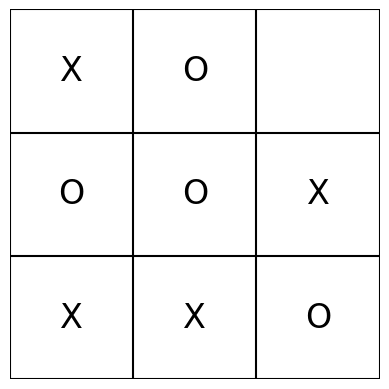

In [24]:
from IPython.display import clear_output
import time

def plot_board(cells, grid_size):
    fig, ax = plt.subplots()
    for i in range(grid_size + 1):
        ax.axhline(i - 0.5, color='black')
        ax.axvline(i - 0.5, color='black')
    for i, cell in enumerate(cells):
        r, c = divmod(i, grid_size)
        if cell == 0:
            label = ''
        elif cell == 1:
            label = 'O'
        else:
            label = 'X'
        ax.text(c, r, label, fontsize=24, ha='center', va='center')
    ax.set_xlim(-0.5, grid_size - 0.5)
    ax.set_ylim(-0.5, grid_size - 0.5)
    ax.set_aspect('equal')
    plt.gca().invert_yaxis()
    plt.axis('off')
    plt.show()

env = TicTacToeEnv(grid_size, win_length)
obs = env.reset()

debug = False

if not debug:
    plot_board(env.cells, grid_size)

for step in range(n_cells):

    if debug:
        print(f"Chunk states: {count_chunk_states()}")
        print(f"Step {step}, Turn: {'O' if env.turn == PLAYER_O else 'X'}")
        print(f"Observation for O: {obs[PLAYER_O]}")
        print(f"Observation for X: {obs[PLAYER_X]}")

        print("Inferring states...")

    qsO = agent_O.infer_states(obs)
    qsX = agent_X.infer_states(obs)

    if debug:
        print("Inferring policies...")

    agent_O.infer_policies()
    agent_X.infer_policies()

    if debug:
        print("Sampling actions...")

    chosen_action_O = agent_O.sample_action()
    
    if debug:
        print("O's policy posterior:", agent_O.q_pi)
        print("O's available policies:", agent_O.policies)
        print("O's sampled action:", chosen_action_O)
    
    chosen_action_X = agent_X.sample_action()
    
    if debug:
        print("X's policy posterior:", agent_X.q_pi)
        print("X's available policies:", agent_X.policies)
        print("X's sampled action:", chosen_action_X)

    # Should always choose a single action as we pass in a filtered policy list
    try:
        mark_action_id_O = np.where(chosen_action_O == 1)[0][0]
        print(f"O's mark action index: {mark_action_id_O}")
    except IndexError:
        raise ValueError("Null action sampled for O")
    try:
        mark_action_id_X = np.where(chosen_action_X == 1)[0][0]
        print(f"X's mark action index: {mark_action_id_X}")
    except IndexError:
        raise ValueError("Null action sampled for X")

    if debug:
        print("Executing action...")

    if env.turn == PLAYER_O:
        obs, reward, done = env.step(mark_action_id_O, agent=PLAYER_O)
    else:  # X's turn
        obs, reward, done = env.step(mark_action_id_X, agent=PLAYER_X)

    if not debug:
        clear_output(wait=True)
        plot_board(env.cells, grid_size)
    
    if grid_size == 3 and win_length == 3 and policy_len == 1:
        time.sleep(1) # Add delay to make it easier to track progress in fast game
    
    if done:
        if reward == 1:
            print('O wins!')
        elif reward == -1:
            print('X wins!')
        else:
            print('Draw!')
        break